# Demonstration of MUSE

This is a demonstration of MUSE analysis on a multi-modality simulated data.

Feng Bao @ Altschuler & Wu Lab @ UCSF 2022.

Software provided as is under MIT License.

## Import packages

In [1]:
import multi_muse_sc as muse
import simulation_tool.multi_modal_simulation as simulation

import phenograph
from sklearn.decomposition import PCA
import numpy as np
from sklearn.metrics.cluster import adjusted_rand_score
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# import tensorflow as tf
# import os
# os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
# tf.get_logger().setLevel('ERROR')
np.random.seed(0)

## Generate simulation data


Simulation parameters

In [2]:
latent_dim = 100
num_cluster = 10
sample_size = 1000
latent_code_dim = 30
observed_data_dim = 500
sigma_1 = 0.1  
sigma_2 = 0.1
decay_coef_1 = 0.5 
decay_coef_2 = 0.1
merge_prob = 0.7



Use simulation tool to generate multi-modality data

In [3]:
data = simulation.multi_modal_simulator(
    num_cluster,
    sample_size,
    observed_data_dim,
    observed_data_dim,
    latent_code_dim,
    sigma_1,
    sigma_2,
    decay_coef_1,
    decay_coef_2,
    merge_prob,
)
data_a = data["data_a_dropout"]
data_b = data["data_b_dropout"]
label_a = data["data_a_label"]
label_b = data["data_b_label"]
label_true = data["true_cluster"]

## Analyses based on single modality

Learn features from single modality

In [4]:
view_a_feature = PCA(n_components=latent_dim).fit_transform(data_a)
view_b_feature = PCA(n_components=latent_dim).fit_transform(data_b)

In [5]:
print(f"data_a shape: {data_a.shape}")
print(f"data_b shape: {data_b.shape}")
print(f"view_a_feature shape: {view_a_feature.shape}")
print(f"view_b_feature shape: {view_b_feature.shape}")

data_a shape: (1000, 500)
data_b shape: (1000, 500)
view_a_feature shape: (1000, 100)
view_b_feature shape: (1000, 100)


Perform clustering using PhenoGraph

In [6]:
view_a_label, _, _ = phenograph.cluster(view_a_feature)
view_b_label, _, _ = phenograph.cluster(view_b_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.08780956268310547 seconds
Jaccard graph constructed in 0.15593290328979492 seconds
Wrote graph to binary file in 0.00549006462097168 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.580098
Louvain completed 21 runs in 0.3810584545135498 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7520589828491211 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.07219243049621582 seconds
Jaccard graph constructed in 0.13893532752990723 seconds
Wrote graph to binary file in 0.004897594451904297 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.670284
Louvain completed 21 runs in 0.3986802101135254 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 0.7296855449676514 seconds


## Combined analysis using MUSE

MUSE learns the joint latent representation

In [7]:
muse_feature, reconstruct_inputs, encoded_inputs = muse.muse_fit_predict(
    [data_a, data_b],
    [view_a_label, view_b_label],
    latent_dim=100,
    n_epochs=500,
    weight_penalty=5,
    triplet_lambda=5,
)

++++++++++ MUSE for multi-modality single-cell analysis ++++++++++
epoch: 0, 	 total loss: 704.08771,	 reconstruction loss: 0.03750,	 sparse penalty: 140.81004
epoch: 50, 	 total loss: 662.67426,	 reconstruction loss: 0.00898,	 sparse penalty: 132.53305
epoch: 100, 	 total loss: 622.96509,	 reconstruction loss: 0.00709,	 sparse penalty: 124.59160
epoch: 150, 	 total loss: 584.74585,	 reconstruction loss: 0.00579,	 sparse penalty: 116.94801
epoch: 0, 	 total loss: 570.96649,	 reconstruction loss: 0.00648,	 sparse penalty: 109.58589,	 triplet loss: 4.60611
epoch: 50, 	 total loss: 528.90436,	 reconstruction loss: 0.00643,	 sparse penalty: 102.49881,	 triplet loss: 3.28079
epoch: 100, 	 total loss: 492.54434,	 reconstruction loss: 0.00636,	 sparse penalty: 95.68541,	 triplet loss: 2.82219
epoch: 150, 	 total loss: 458.89929,	 reconstruction loss: 0.00635,	 sparse penalty: 89.14664,	 triplet loss: 2.63195
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors co

## Perform clustering
PhenoGraph clustering

In [8]:
muse_label, _, _ = phenograph.cluster(muse_feature)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06741929054260254 seconds
Jaccard graph constructed in 0.34044504165649414 seconds
Wrote graph to binary file in 0.0033860206604003906 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.923108
Louvain completed 21 runs in 0.8386383056640625 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.551269292831421 seconds


## Visualization of latent spaces 
Latent spaces of single-modality features or MUSE features were visualized using tSNE, with ground truth cluster labels.

Cluster accuries were quantified using adjusted Rand index (ARI). ARI = 1 indicates perfectly discover true cell identities.

view_a_feature: (1000, 100)
X_embedded: (1000, 2)
label_true: (1000,)
laber_true == i: (1000,)
np.nonzero(label_true == i): 86


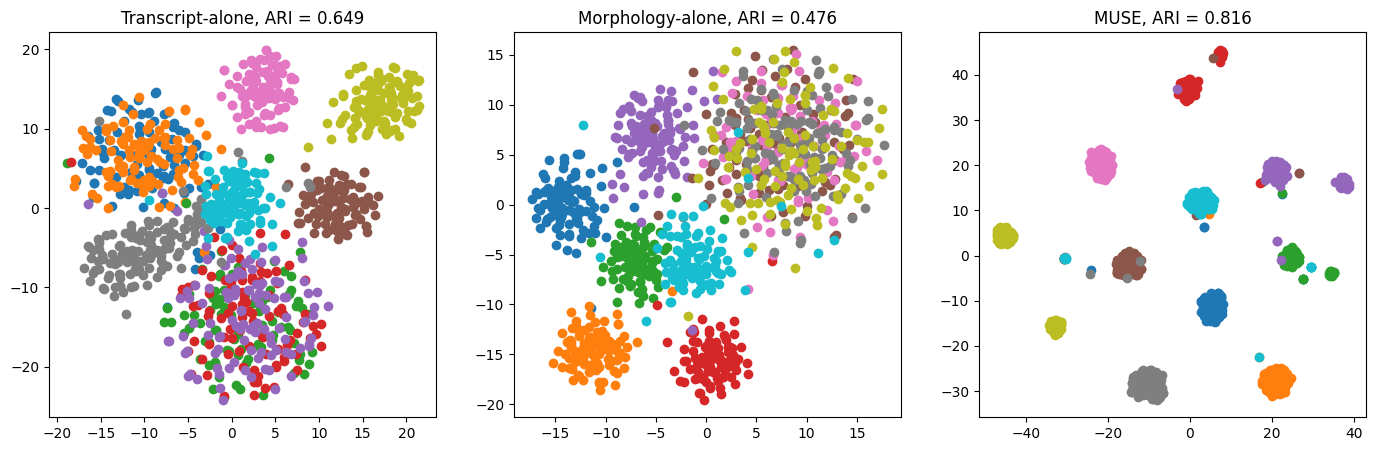

In [9]:
plt.figure(figsize=(17, 5))
plt.subplot(1, 3, 1)
print(f"view_a_feature: {view_a_feature.shape}")
X_embedded = TSNE(n_components=2).fit_transform(view_a_feature)
print(f"X_embedded: {X_embedded.shape}")
print(f"label_true: {label_true.shape}")
print(f"laber_true == i: {(label_true == 0).shape}")
print(f"np.nonzero(label_true == i): {len(np.nonzero(label_true == 2)[0])}")
# 遍历每一个类别
for i in np.unique(label_true):
    # 找到所有类别为i的索引
    idx = np.nonzero(label_true == i)[0]
    # 将类别为i的点画成散点图
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    # 设置标题
    plt.title('Transcript-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_a_label))

plt.subplot(1, 3, 2)
X_embedded = TSNE(n_components=2).fit_transform(view_b_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('Morphology-alone, ARI = %01.3f' % adjusted_rand_score(label_true, view_b_label))

plt.subplot(1, 3, 3)
X_embedded = TSNE(n_components=2).fit_transform(muse_feature)
for i in np.unique(label_true):
    idx = np.nonzero(label_true == i)[0]
    plt.scatter(X_embedded[idx, 0], X_embedded[idx, 1])
    plt.title('MUSE, ARI = %01.3f' % adjusted_rand_score(label_true, muse_label))